In [1]:
import pandas as pd

reports_df = pd.read_csv("preprocessed_content.csv")
sasb_df = pd.read_csv("esg_sasb_data.csv")

print(reports_df.shape)
print(sasb_df.shape)

(866, 10)
(6460, 3)


In [3]:
print(sasb_df.columns.tolist())

['Text', 'Parent Label', 'Child Label']


In [4]:
import re

def create_greenwashing_label(text):

    text = str(text).lower()

    if re.search(r"\d+%", text):
        return "Concrete"

    if re.search(r"\d+\s*(tons|tonnes|kg|mw)", text):
        return "Concrete"

    vague_words = [
        "committed",
        "commitment",
        "sustainable",
        "green",
        "eco",
        "responsible",
        "future",
        "environmentally friendly"
    ]

    for word in vague_words:
        if word in text:
            return "Vague"

    return "Unverifiable"

In [5]:
sasb_df["Greenwashing_Label"] = sasb_df["Text"].apply(
    create_greenwashing_label
)

In [6]:
print(sasb_df.columns.tolist())

['Text', 'Parent Label', 'Child Label', 'Greenwashing_Label']


In [7]:
sasb_df["Greenwashing_Label"].value_counts()

Greenwashing_Label
Unverifiable    5360
Vague            888
Concrete         212
Name: count, dtype: int64

In [8]:
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

X = sbert.encode(
    sasb_df["Text"].astype(str).tolist(),
    show_progress_bar=True
)

C:\Users\HP\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Batches: 100%|██████████| 202/202 [00:46<00:00,  4.31it/s]


In [9]:
label_map = {
    "Concrete":0,
    "Vague":1,
    "Unverifiable":2
}

y = sasb_df["Greenwashing_Label"].map(label_map)

In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [12]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=3000),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            random_state=42
        )
}

In [13]:
results = []

for name,model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        pred
    )

    results.append(
        [name,acc]
    )

    print(name,acc)

Logistic Regression 0.8297213622291022
Random Forest 0.8057275541795665
XGBoost 0.8227554179566563


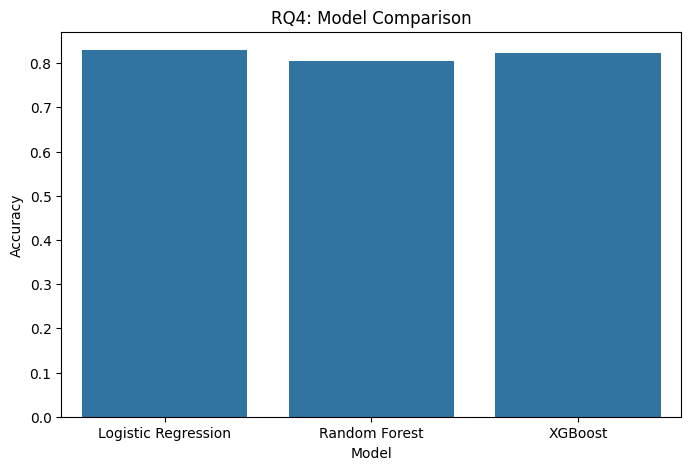

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title(
    "RQ4: Model Comparison"
)

plt.show()

In [15]:
best_model = XGBClassifier(
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [17]:
reverse_map = {

    0:"Concrete",

    1:"Vague",

    2:"Unverifiable"
}

def classify_claim(text):

    emb = sbert.encode([str(text)])

    pred = best_model.predict(
        emb
    )[0]

    return reverse_map[pred]

In [18]:
import re

In [19]:
def split_sentences(text):

    return re.split(
        r'[.!?]+',
        str(text)
    )

In [20]:
def greenwashing_score(labels):

    concrete = labels.count(
        "Concrete"
    )

    vague = labels.count(
        "Vague"
    )

    unverifiable = labels.count(
        "Unverifiable"
    )

    score = (

        vague

        + 2*unverifiable

        - concrete

    )

    return max(score,0)

In [21]:
scores = []

In [22]:
for report in reports_df[
    "preprocessed_content"
].fillna(""):

    sentences = split_sentences(
        report
    )

    labels = []

    for sentence in sentences[:100]:

        if len(sentence.strip()) > 10:

            labels.append(
                classify_claim(sentence)
            )

    score = greenwashing_score(
        labels
    )

    scores.append(score)

In [23]:
reports_df[
    "greenwashing_score"
] = scores

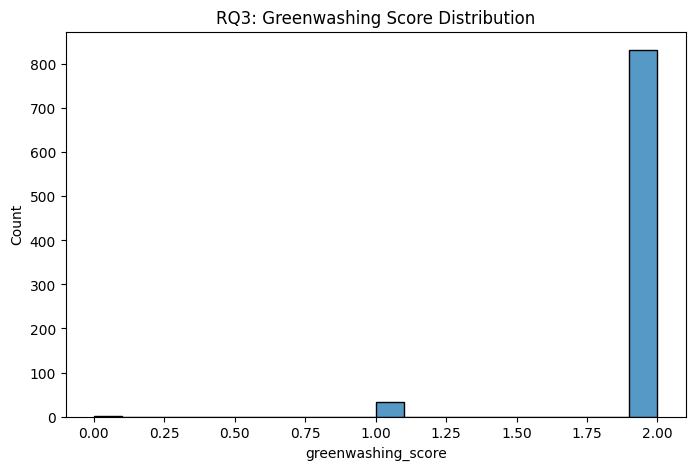

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    reports_df[
        "greenwashing_score"
    ],
    bins=20
)

plt.title(
    "RQ3: Greenwashing Score Distribution"
)

plt.show()

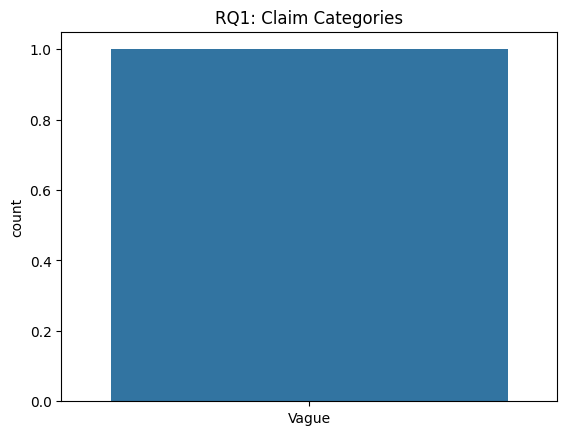

In [25]:
sample_report = reports_df[
    "preprocessed_content"
].dropna().iloc[0]
sample_sentences = split_sentences(
    sample_report
)

sample_labels = [

    classify_claim(s)

    for s in sample_sentences[:100]

    if len(s)>10
]

sns.countplot(
    x=sample_labels
)

plt.title(
    "RQ1: Claim Categories"
)

plt.show()

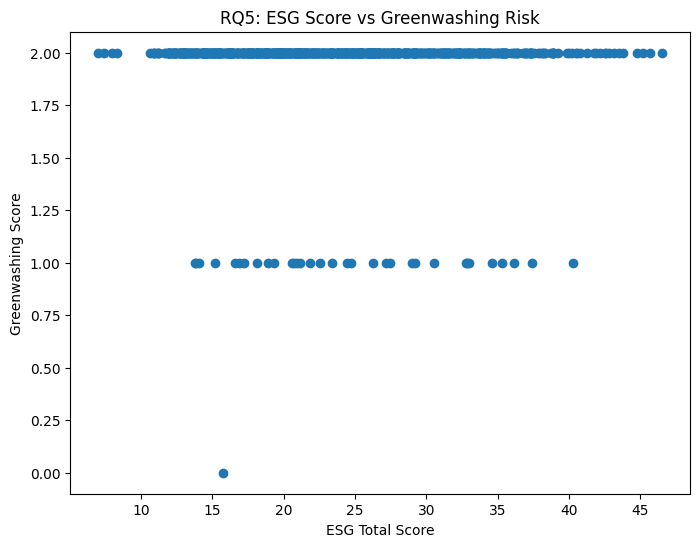

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(

    reports_df["total_score"],

    reports_df["greenwashing_score"]
)

plt.xlabel(
    "ESG Total Score"
)

plt.ylabel(
    "Greenwashing Score"
)

plt.title(
    "RQ5: ESG Score vs Greenwashing Risk"
)

plt.show()

In [27]:
corr = reports_df[
    ["total_score",
     "greenwashing_score"]
].corr()

print(corr)

                    total_score  greenwashing_score
total_score            1.000000           -0.015992
greenwashing_score    -0.015992            1.000000


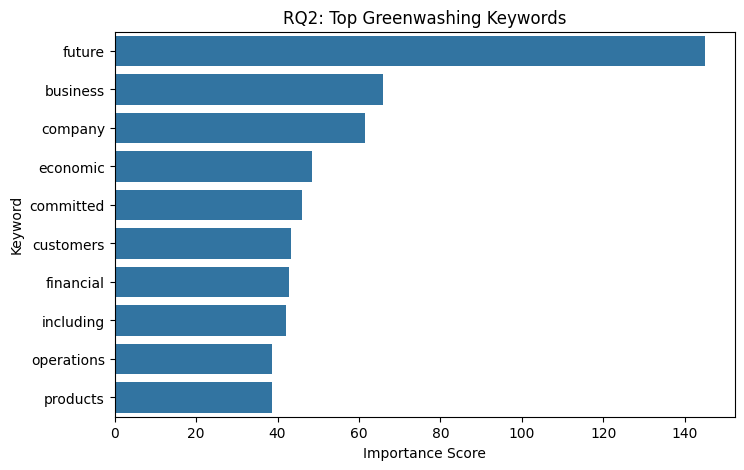

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vague_text = sasb_df[
    sasb_df["Greenwashing_Label"] == "Vague"
]["Text"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

X_tfidf = vectorizer.fit_transform(
    vague_text.astype(str)
)

import pandas as pd

scores = X_tfidf.sum(axis=0).A1

terms = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame({
    "term": terms,
    "score": scores
})

tfidf_df = tfidf_df.sort_values(
    by="score",
    ascending=False
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=tfidf_df.head(10),
    x="score",
    y="term"
)

plt.title(
    "RQ2: Top Greenwashing Keywords"
)

plt.xlabel("Importance Score")

plt.ylabel("Keyword")

plt.show()

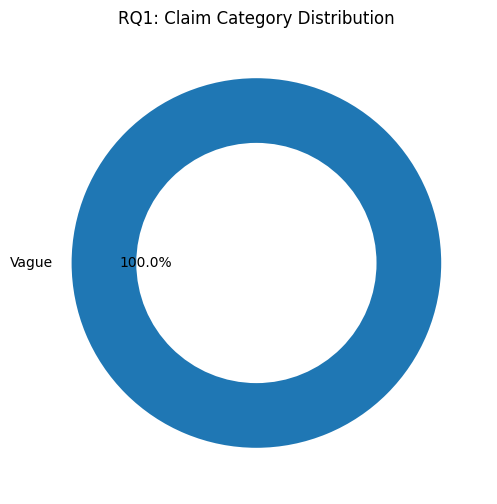

In [30]:
## test

import matplotlib.pyplot as plt

counts = pd.Series(sample_labels).value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.65,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("RQ1: Claim Category Distribution")

plt.show()

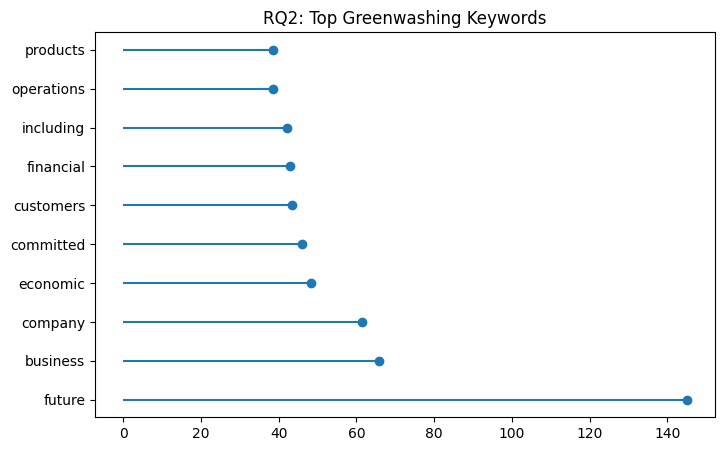

In [31]:
plt.figure(figsize=(8,5))

plt.hlines(
    y=tfidf_df.head(10)["term"],
    xmin=0,
    xmax=tfidf_df.head(10)["score"]
)

plt.plot(
    tfidf_df.head(10)["score"],
    tfidf_df.head(10)["term"],
    "o"
)

plt.title(
    "RQ2: Top Greenwashing Keywords"
)

plt.show()

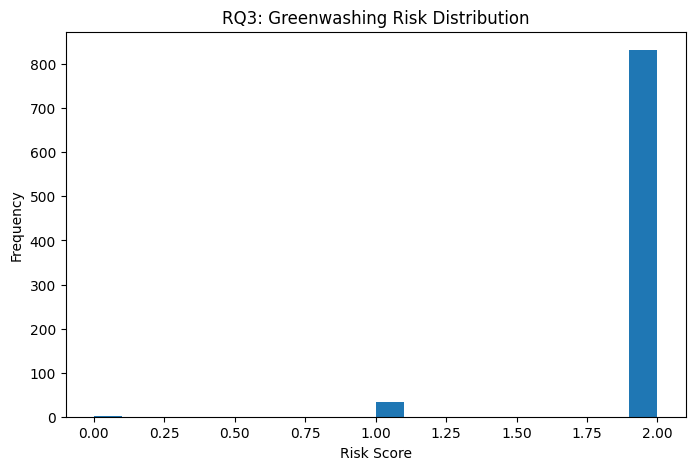

In [32]:
plt.figure(figsize=(8,5))

plt.hist(
    reports_df["greenwashing_score"],
    bins=20
)

plt.title(
    "RQ3: Greenwashing Risk Distribution"
)

plt.xlabel("Risk Score")

plt.ylabel("Frequency")

plt.show()

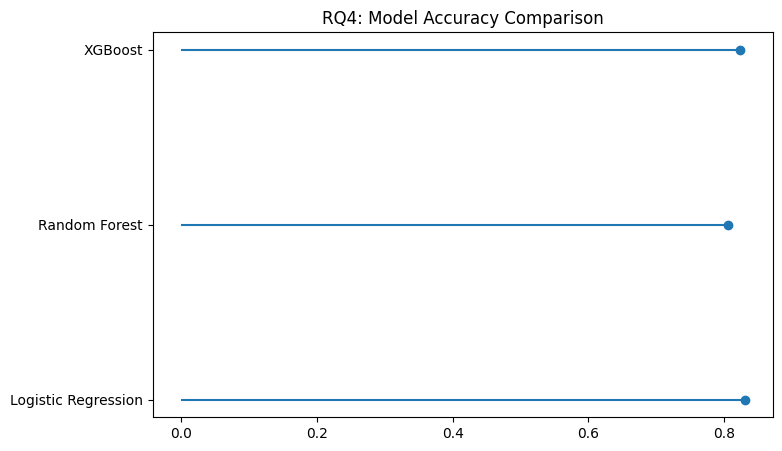

In [33]:
plt.figure(figsize=(8,5))

plt.hlines(
    y=results_df["Model"],
    xmin=0,
    xmax=results_df["Accuracy"]
)

plt.plot(
    results_df["Accuracy"],
    results_df["Model"],
    "o"
)

plt.title(
    "RQ4: Model Accuracy Comparison"
)

plt.show()

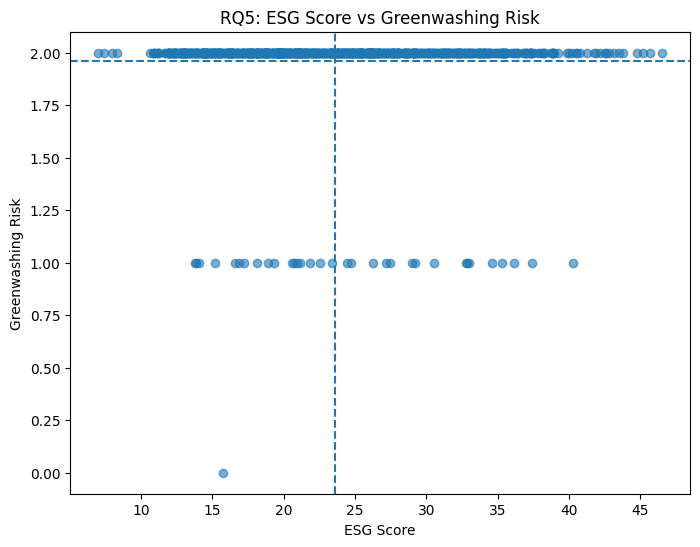

In [34]:
plt.figure(figsize=(8,6))

plt.scatter(
    reports_df["total_score"],
    reports_df["greenwashing_score"],
    alpha=0.6
)

plt.axhline(
    reports_df["greenwashing_score"].mean(),
    linestyle="--"
)

plt.axvline(
    reports_df["total_score"].mean(),
    linestyle="--"
)

plt.xlabel("ESG Score")

plt.ylabel("Greenwashing Risk")

plt.title(
    "RQ5: ESG Score vs Greenwashing Risk"
)

plt.show()